# Covid Workshop

by Kaylee Vo

In [64]:
# !pip3 install --upgrade pandas
import matplotlib.dates as mdates
import matplotlib.pylab as plt
import numpy as np
import pandas as pd
import statsmodels.api as sm
from scipy.integrate import solve_ivp
from scipy.interpolate import interp1d
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder

In [65]:
# Customize for matplotlib
# If interested in the matplotlib object hierarchy, check: https://realpython.com/python-matplotlib-guide/
plt.rcParams["axes.linewidth"] = 1
plt.rcParams["xtick.bottom"] = True
plt.rcParams["ytick.left"] = True
plt.rcParams["xtick.direction"] = "in"
plt.rcParams["ytick.direction"] = "in"
plt.rcParams["mathtext.default"] = "regular"
# Change font size: http://www.futurile.net/2016/02/27/matplotlib-beautiful-plots-with-style/
plt.rcParams["font.size"] = 12
plt.rcParams["axes.labelsize"] = 14
plt.rcParams["axes.labelweight"] = "bold"
plt.rcParams["xtick.labelsize"] = 12
plt.rcParams["ytick.labelsize"] = 12
plt.rcParams["legend.fontsize"] = 14
plt.rcParams["figure.titlesize"] = 20

In [66]:
# This code gives an example of how to read in the csv data and a template
# for the workshop

# change this to the path for your data
datapath = "./"

filename = "US_states_population.csv"

# Load the data
try:
    population_table = pd.read_csv(f"{datapath}{filename}")
except FileNotFoundError:
    raise FileNotFoundError(f"Could not find file: {datapath}{filename}")

# Define the target state ID
state_id = 544

# Filter the DataFrame for the specified state ID
state_row = population_table[population_table["LocationID"] == state_id]

# Check if the state was found
if not state_row.empty:
    state_name = state_row["StateName"].values[0]
    population = state_row["Population"].values[0]
    print(f"State: {state_name}, Population: {population}")
else:
    print(f"No state found with LocationID = {state_id}")

# read in the state ID and state population
PopulationTable = pd.read_csv(datapath + "US_states_population.csv")

# choose a state
stateid = 544

rowindex = PopulationTable.LocationID == stateid
# find the corresponding row
PopulationTable.StateName[rowindex]  # state name
N = PopulationTable.Population[rowindex]
# total state population

State: Massachusetts, Population: 6665095


In [67]:
def read_covid_data(filename, state_id):
    """
    Reads time series COVID-related data for a specific state.

    Parameters:
    - filename (str): Path to the CSV file.
    - state_id (int): The LocationID of the state to filter.

    Returns:
    - pd.DataFrame: A DataFrame with 'date' as index and 'mean' values.
    """
    # Load the data
    try:
        df = pd.read_csv(filename)
    except FileNotFoundError:
        raise FileNotFoundError(f"File not found: {filename}")

    # Validate required columns
    required_columns = {"location_id", "date", "mean"}
    if not required_columns.issubset(df.columns):
        raise ValueError(
            f"Missing required columns: {required_columns - set(df.columns)}"
        )

    # Filter for the specified state ID
    state_df = df[df["location_id"] == state_id][["date", "mean"]]

    if state_df.empty:
        raise ValueError(f"No data found for state ID {state_id} in file {filename}")

    # Convert date to datetime and set it as index
    state_df["date"] = pd.to_datetime(state_df["date"])
    state_df.set_index("date", inplace=True)

    return state_df

In [68]:
# Read in daily infection, mobility, and mask use data for a specific state
infection = read_covid_data(f"{datapath}daily_infections.csv", state_id)
mobility = read_covid_data(f"{datapath}mobility.csv", state_id)
mask_use = read_covid_data(f"{datapath}mask_use.csv", state_id)

# Merge all three datasets using outer join on the date index
data = infection.join(mobility, how="outer", lsuffix="_infection").join(
    mask_use, how="outer", lsuffix="_mobility", rsuffix="_mask_use"
)

# Filter the data to only include dates from Feb 1, 2020 to Sep 21, 2020
analysis_start = pd.to_datetime("2020-02-01")
analysis_end = pd.to_datetime("2020-09-21")
data = data.loc[analysis_start:analysis_end]

# Optional: Check and report missing data
if data.isnull().values.any():
    print("Warning: Missing values detected after merging datasets.")

## Activity 1: using the number of new infections given, determine 𝛽(t) using Eq. (1)

### Part 1a

**Given f(t), integrate Eq. (1) using an ODE solver to find S(t), I1(t), I2(t). We shall assume f is
constant within each day.**

In [69]:
def seiid(
    t, X, f_data, t_data, sigma=0.25, gamma_1=0.5, gamma_2=2 / 3.0, alpha=0.95, N=1000
):

    S = X[0]
    E = X[1]
    i1 = X[2]
    i2 = X[3]
    r = X[4]

    # interpolate the daily data
    f = np.interp(t, t_data, f_data)

    # alternative approach: assume f is constant within each day
    # f_interp = interp1d(
    #     t_data,
    #     f_data,
    #     kind="previous",
    #     bounds_error=False,
    #     fill_value=(f_data[0], f_data[-1])
    # )
    # f = f_interp(t)

    # Define the ODEs given in Equation (1)
    ds = -1 * f
    dE = f - sigma * E
    dI1 = sigma * E - gamma_1 * i1
    dI2 = gamma_1 * i1 - gamma_2 * i2
    dr = gamma_2 * i2

    return [ds, dE, dI1, dI2, dr]

- We set the parameters for $\sigma$, $\gamma_1$, and $\gamma_2$ using default function arguments.
- We leave the option to have a different interpolation function, where $f$ is assumed to be constant within each day. The option was tested, but it deviated more from the data than the linear interpolation.


In [70]:
# date indices
T_end = len(data)
t_data = np.arange(T_end)
f_data = data["mean_infection"].values

In [71]:
# Inputs into the ODE solver
tspan = [0.0, T_end]
t_eval = np.arange(0, T_end, 1)
X0 = [N.values[0] - 1, 1, 0, 0, 0]  # S, E, I1, I2, R

- We start with one exposed individual.

In [72]:
sol = solve_ivp(
    seiid,
    tspan,
    X0,
    args=[
        data["mean_infection"].values,
        t_data,
    ],
    method="Radau",
    t_eval=t_eval,
)
# Unpack solution
T, X = sol.t, sol.y

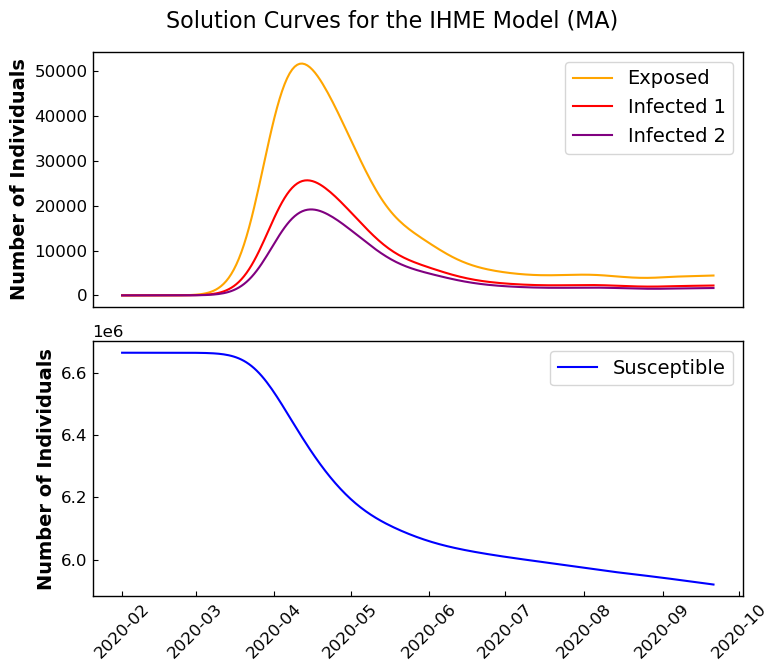

In [73]:
fig, ax = plt.subplots(2, 1, figsize=(8, 6))
ax[0].plot(T, X[1], label="Exposed", color="orange")
ax[0].plot(T, X[2], label="Infected 1", color="red")
ax[0].plot(T, X[3], label="Infected 2", color="purple")
ax[0].set_xticks([])
ax[0].set_ylabel("Number of Individuals")
ax[0].legend()

ax[1].plot(data.index, X[0], label="Susceptible", color="blue")
ax[1].legend()
ax[1].set_ylabel("Number of Individuals")

plt.tight_layout()
plt.xticks(rotation=45)

plt.suptitle("Solution Curves for the IHME Model (MA)", fontsize=16, y=1.04)
plt.show()

- As a quick sanity check, we compute the total number of infected individuals from the model and compare it to the total number of infected individuals in the data. As we can see, the model and data are close.

In [74]:
total_infected_model = X[0, 0] - X[0, -1]
total_infected_data = data["mean_infection"].sum()

print("Total Infected (Model):", round(total_infected_model, 4))
print("Total Infected (Data):", round(total_infected_data, 4))
print("Difference:", round(total_infected_model - total_infected_data, 4))

Total Infected (Model): 745409.523
Total Infected (Data): 745995.0218
Difference: -585.4988


- To get a more accurate estimate of the total number of infected individuals, we can use the trapezoidal rule to integrate the data. We can see the numbers are very close.

In [75]:
total_infected_model = X[0, 0] - X[0, -1]
total_infected_data = np.trapz(data["mean_infection"].values, t_data)

print("Total Infected (Model):", round(total_infected_model, 4))
print("Total Infected (Data):", round(total_infected_data, 4))
print("Difference:", round(total_infected_model - total_infected_data, 4))

Total Infected (Model): 745409.523
Total Infected (Data): 745430.4533
Difference: -20.9303


### Part 1b

**Interpolate the solution to daily resolution, then use Eq. (2) to solve for $\beta(t)$. My solution of $\beta(t)$ is included in betas.csv for you to compare with. I started the simulation from Feb. 1, 2020.**

After solving for $\beta(t)$, we get the expression:

$$
\beta(t) = \frac{f(t) N}{S(I_1 + I_2)^\alpha}.
$$

In [76]:
S = X[0]
I1 = X[2]
I2 = X[3]
alpha = 0.95
N_pop = N.values[0]
ft = data["mean_infection"].values

# Adding a small value to avoid division by zero
beta_t = (ft * N_pop) / (S * (I1 + I2) ** alpha + 1e-10)

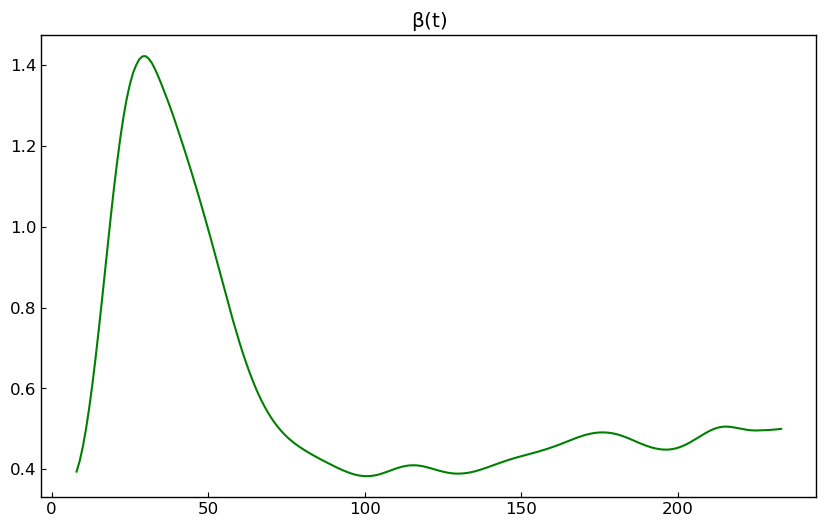

In [77]:
fig, ax = plt.subplots(figsize=(10, 6))

start_index = 8
ax.plot(
    T[start_index:],
    beta_t[start_index:],
    label="Effective Reproduction Number",
    color="green",
)
ax.set_title("$\\beta(t)$")
plt.show()

- We ignore the first 10 days of the data because it is very noisy.
- The data is noisy because the number of new infections is very small at the beginning of the pandemic, which makes the denominator in Eq. (2) very small, leading to noisy, large values of $\beta(t)$.

Now, let's compare our solution with the solution given.


In [78]:
solution_beta = pd.read_csv("betas_zhiming.csv")
solution_beta

,date,location_id,location_name,mean
0,2020-02-01,523,Alabama,NaN
1,2020-02-02,523,Alabama,NaN
2,2020-02-03,523,Alabama,NaN
3,2020-02-04,523,Alabama,NaN
4,2020-02-05,523,Alabama,NaN
...,...,...,...,...
11929,2020-09-17,573,Wyoming,0.349026
11930,2020-09-18,573,Wyoming,0.341761
11931,2020-09-19,573,Wyoming,0.334114
11932,2020-09-20,573,Wyoming,0.326048


In [79]:
mass_data_solution = solution_beta[solution_beta["location_name"] == "Massachusetts"]

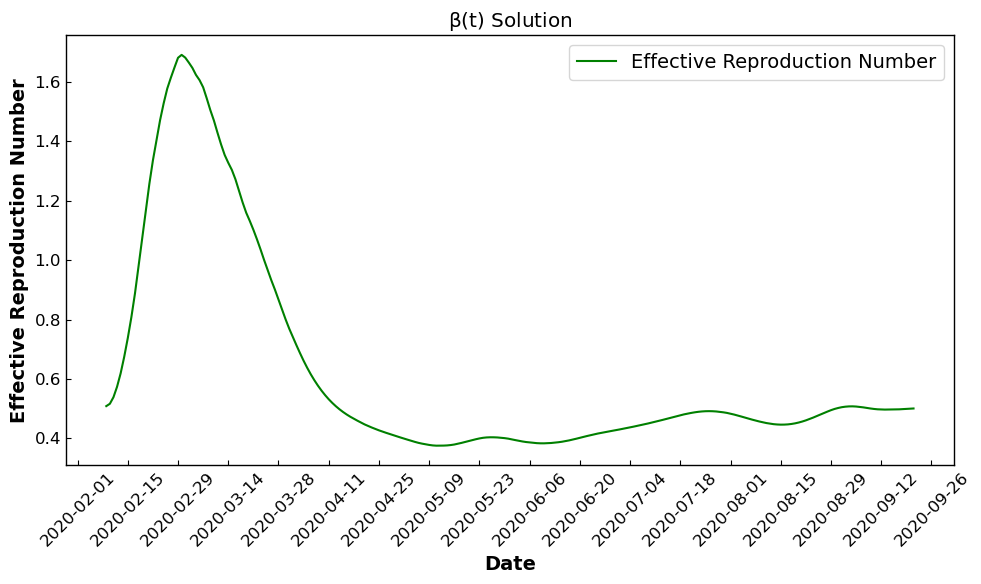

In [80]:
fig, ax = plt.subplots(figsize=(10, 6))

# To ignore the noisy first parts
dates = mass_data_solution["date"][start_index:].apply(pd.to_datetime)
values = mass_data_solution["mean"][start_index:]

ax.plot(dates, values, label="Effective Reproduction Number", color="green")
ax.set_title("$\\beta(t)$ Solution")
ax.set_xlabel("Date")
ax.set_ylabel("Effective Reproduction Number")

ax.xaxis.set_major_locator(mdates.DayLocator(interval=14))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m-%d"))

plt.xticks(rotation=45)
ax.legend()
plt.tight_layout()
plt.show()

- The solution derived from this notebook is close to the one given in the file betas.csv for the state of Massachusetts.

Now we loop over all states and compute $\beta(t)$ for each state. We can then compare the results with the data given in betas.csv.

In [81]:
# Store the dataframes for each state
state_dfs = []
state_ids = population_table["LocationID"].unique()

for state_id in state_ids:
    # Filter the DataFrame for the specified state ID
    state_row = population_table[population_table["LocationID"] == state_id]

    # Check if the state was found
    if not state_row.empty:
        state_name = state_row["StateName"].values[0]
        population = state_row["Population"].values[0]
        print(f"State: {state_name}, Population: {population}")
    else:
        print(f"No state found with LocationID = {state_id}")

    # read in the state ID and state population
    PopulationTable = pd.read_csv(datapath + "US_states_population.csv")

    # choose a state
    stateid = 544

    rowindex = PopulationTable.LocationID == stateid
    # find the corresponding row
    PopulationTable.StateName[rowindex]  # state name
    N = PopulationTable.Population[rowindex]
    # total state population

    #### Get Data ###
    # Read in daily infection, mobility, and mask use data for a specific state
    infection = read_covid_data(f"{datapath}daily_infections.csv", state_id)
    mobility = read_covid_data(f"{datapath}mobility.csv", state_id)
    mask_use = read_covid_data(f"{datapath}mask_use.csv", state_id)

    # Merge all three datasets using outer join on the date index
    data = infection.join(mobility, how="outer", lsuffix="_infection").join(
        mask_use, how="outer", lsuffix="_mobility", rsuffix="_mask_use"
    )

    # Filter the data to only include dates from Feb 1, 2020 to Sep 21, 2020
    analysis_start = pd.to_datetime("2020-02-01")
    analysis_end = pd.to_datetime("2020-09-21")
    data = data.loc[analysis_start:analysis_end]

    # Optional: Check and report missing data
    if data.isnull().values.any():
        print("Warning: Missing values detected after merging datasets.")

    ### Solve ODE ###
    # date indices
    T_end = len(data)
    t_data = np.arange(T_end)
    f_data = data["mean_infection"].values

    # Inputs into the ODE solver
    tspan = [0.0, T_end]
    t_eval = np.arange(0, T_end, 1)
    X0 = [N.values[0] - 1, 1, 0, 0, 0]  # S, E, I1, I2, R

    sol = solve_ivp(
        seiid,
        tspan,
        X0,
        args=[
            data["mean_infection"].values,
            t_data,
        ],
        method="Radau",
        t_eval=t_eval,
    )
    # Unpack solution
    T, X = sol.t, sol.y

    S = X[0]
    I1 = X[2]
    I2 = X[3]
    alpha = 0.95
    N_pop = N.values[0]
    ft = data["mean_infection"].values

    # Adding a small value to avoid division by zero
    beta_t = (ft * N_pop) / (S * (I1 + I2) ** alpha + 1e-10)

    state_df = {
        "date": data.index,
        "location_id": state_id,
        "location_name": state_row["StateName"].values[0],
        "mean": beta_t,
    }

    state_dfs.append(state_df)

State: Alabama, Population: 4977688
State: Alaska, Population: 788027
State: Arizona, Population: 7249679
State: Arkansas, Population: 3057348
State: California, Population: 39872032
State: Colorado, Population: 5401063
State: Connecticut, Population: 3693747
State: Delaware, Population: 975095
State: District of Columbia, Population: 650224
State: Florida, Population: 21174892
State: Georgia, Population: 10668125
State: Hawaii, Population: 1487442
State: Idaho, Population: 1735118
State: Illinois, Population: 13042506
State: Indiana, Population: 6719600
State: Iowa, Population: 3130718
State: Kansas, Population: 2969705
State: Kentucky, Population: 4504876
State: Louisiana, Population: 4588275
State: Maine, Population: 1353538
State: Maryland, Population: 6142347
State: Massachusetts, Population: 6665095
State: Michigan, Population: 9712914
State: Minnesota, Population: 5565821
State: Mississippi, Population: 3003693
State: Missouri, Population: 6242956
State: Montana, Population: 103

In [82]:
# Convert each dict to a DataFrame
# Concatenate all DataFrames vertically
beta_dfs = [pd.DataFrame(d) for d in state_dfs]
beta_df = pd.concat(beta_dfs, ignore_index=True)

In [83]:
solution_beta = solution_beta[solution_beta["date"] >= "2020-03-13"]
solution_beta = solution_beta.reset_index(drop=True)
beta_df = beta_df[beta_df["date"] >= "2020-03-13"]
beta_df = beta_df.reset_index(drop=True)

- It is understood that the cutoff we are to use as defined in the workshop specs is March 11, 2020, but we use March 13, 2020, instead, because the data was still messy on March 11, 2020. Past that date, the data is much cleaner and more reliable.


In [84]:
max_diff = max(solution_beta["mean"] - beta_df["mean"])
np.argmax_diff = np.argmax(solution_beta["mean"] - beta_df["mean"])
solution_beta.iloc[np.argmax_diff], beta_df.iloc[np.argmax_diff]

(date             2020-03-13
 location_id             530
 location_name      Delaware
 mean               20.89366
 Name: 1351, dtype: object,
 date             2020-03-13 00:00:00
 location_id                      530
 location_name               Delaware
 mean                        8.624252
 Name: 1351, dtype: object)

## Activity 2: estimate the effect of mobility and mask use on the spread rate $\beta(t)$

### Part 2a: Perform a linear regression of log 𝛽(t) against mobility and mask use.

- The first step is to loop over all states and demean the features of interest. This is equivalent to running a fixed effects regression, where each state has its own intercept.


In [85]:
fit_dfs = []


for state_id in state_ids:
    # Block of code borrowed from above
    # Read in daily infection, mobility, and mask use data for a specific state
    infection = read_covid_data(f"{datapath}daily_infections.csv", state_id)
    mobility = read_covid_data(f"{datapath}mobility.csv", state_id)
    mask_use = read_covid_data(f"{datapath}mask_use.csv", state_id)

    # Merge all three datasets using outer join on the date index
    data = infection.join(mobility, how="outer", lsuffix="_infection").join(
        mask_use, how="outer", lsuffix="_mobility", rsuffix="_mask_use"
    )

    # Filter the data to only include dates from Feb 1, 2020 to Sep 21, 2020
    analysis_start = pd.to_datetime("2020-02-01")
    analysis_end = pd.to_datetime("2020-09-21")
    data = data.loc[analysis_start:analysis_end]

    # Start fitting from March 11, 2020 (to avoid early-pandemic estimation issues)
    fit_start_date = pd.to_datetime("2020-03-13")
    fit_data = data.loc[fit_start_date:].copy()

    # Extract mobility and mask use time series for fitting
    mask_series = fit_data["mean_mask_use"]
    mobility_series = fit_data["mean_mobility"]

    # Demean
    fit_data["mean_mask_use_demeaned"] = mask_series - mask_series.mean()
    fit_data["mean_mobility_demeaned"] = mobility_series - mobility_series.mean()
    fit_data["state_id"] = state_id

    fit_dfs.append(fit_data)

# Concatenate all state DataFrames into a single DataFrame
fit_data = pd.concat(fit_dfs, axis=0)

In [86]:
fit_data.head()

,mean_infection,mean_mobility,mean_mask_use,mean_mask_use_demeaned,mean_mobility_demeaned,state_id
date,,,,,,
2020-03-13,525.284575,-1.322054,0.000925,-0.323524,13.383953,523
2020-03-14,605.872264,-3.538032,0.001222,-0.323228,11.167976,523
2020-03-15,689.772447,-6.028823,0.001615,-0.322834,8.677184,523
2020-03-16,775.189133,-8.718338,0.002134,-0.322316,5.987669,523
2020-03-17,860.090744,-11.514828,0.002814,-0.321636,3.191180,523


In [87]:
beta_df = beta_df.rename(columns={"mean": "beta"})
beta_df.head()

,date,location_id,location_name,beta
0,2020-03-13,523,Alabama,1.048987
1,2020-03-14,523,Alabama,1.006630
2,2020-03-15,523,Alabama,0.963842
3,2020-03-16,523,Alabama,0.921581
4,2020-03-17,523,Alabama,0.879868


In [88]:
# set zero to small number in beta_df
# before the log transformation to avoid log(0)
beta_df["beta"] = beta_df["beta"].replace(0, 1e-10)

In [89]:
y = np.log(beta_df["beta"])
X = fit_data[["mean_mobility_demeaned", "mean_mask_use_demeaned"]]

model = LinearRegression()
model.fit(X, y)

LinearRegression()

In [90]:
r2_score = model.score(X, y)
print("R^2 score:", round(r2_score, 4))

R^2 score: 0.1841


In [91]:
feature_names = ["mean_mobility_demeaned", "mean_mask_use_demeaned"]
coefs = model.coef_

for name, coef in list(zip(feature_names, coefs))[-2:]:
    print(f"Coefficient for {name}: {coef:.4f}")

Coefficient for mean_mobility_demeaned: 0.0100
Coefficient for mean_mask_use_demeaned: -1.2521


In [92]:
# In percentage
print(round((np.exp(coefs[-2]) - 1) * 100, 4))
print(round((np.exp(coefs[-1]) - 1) * 100, 4))

1.0044
-71.4096


### Part 2b: What assumption are we making regressing log bt instead of bt?

- the interpretation coefficient is that one unit change in $X$ is a percentage change in $Y$ by $\beta_t$, holding all other regressors constant.
- We are also assuming that the original data has no zero values; otherwise a log transformation would not be valid.
- We are also assuming that the errors are log-normally distributed instead of normal.

### Part 2C: Examine the fit and the contributions from mobility and mask use. Write down your thoughts about the fit. If time permits, examine whether the assumptions for Ordinary Least Squares are valid.

- The fit is decent. The $R^2$ is 0.184, which means that only 18.4% of the variance in $\log(\beta_t)$ is explained by the model.
- However, the direction of the coefficients makes sense. Increasing mobility increases $\beta(t)$ by around 1% and increasing mask use decreases $\beta(t)$ by around 71%.
    - https://pmc.ncbi.nlm.nih.gov/articles/PMC9125347/
    - https://pmc.ncbi.nlm.nih.gov/articles/PMC8275478/
    - The source puts mask usage at around a 70% reduced risk of infection rate. The estimate is surprisingly close to the one we got from the regression.
    - The source suggests that a 1% decrease in mobility is associated with a 1.9%  decrease in total cases. This is also surprisingly close to the one we got from the regression.

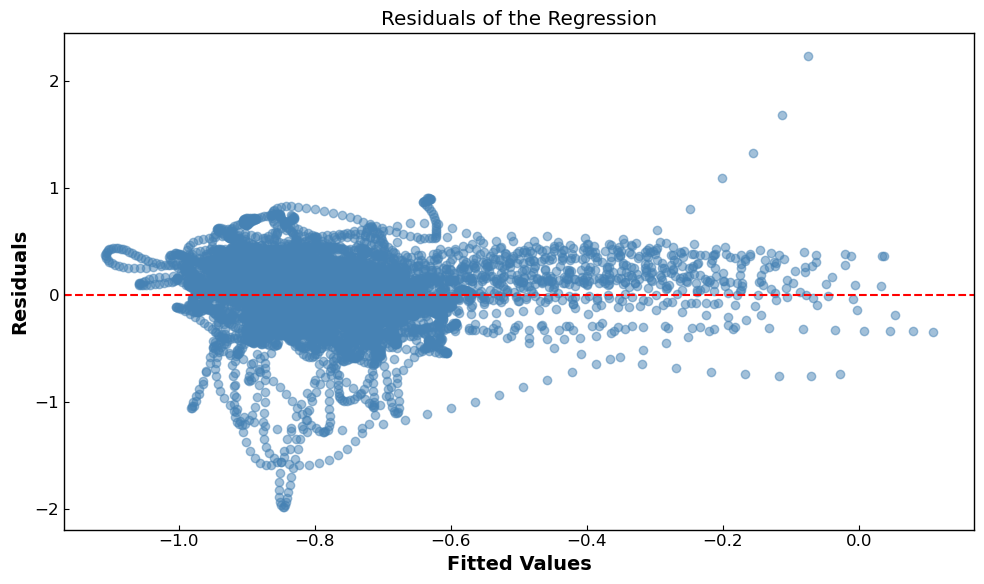

In [93]:
# plot the residuals

prediction = model.predict(X)
residual = y - prediction

fig, ax = plt.subplots(figsize=(10, 6))
ax.scatter(prediction, residual, color="steelblue", alpha=0.5)
ax.set_xlabel("Fitted Values")
ax.set_ylabel("Residuals")
ax.set_title("Residuals of the Regression")
plt.axhline(0, color="red", linestyle="--")
plt.tight_layout()
plt.show()

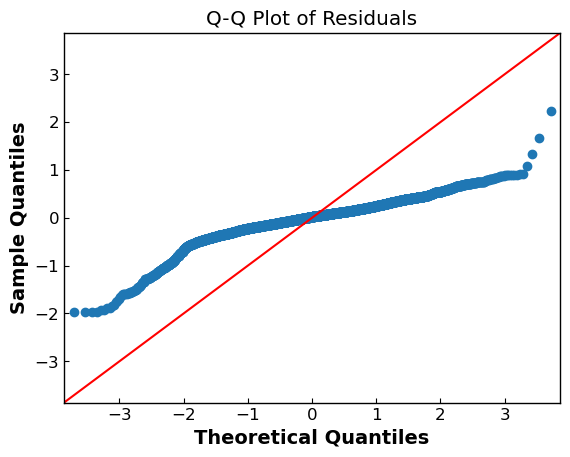

In [94]:
# Create Q-Q plot
fig = sm.qqplot(residual, line="45")
plt.title("Q-Q Plot of Residuals")
plt.show()

- The assumptions of OLS are not satisfied. The residuals are not normally distributed, and the errors are not homoskedastic. The residuals do not look like white noise. There are clear patterns, and the variance in the residuals is not constant across the range of fitted values.
- However, the residuals are centered around zero, which suggests that the relationship may be linear between log $\beta(t)$ and the regressors.


## Sources
1. https://stackoverflow.com/questions/14946371/editing-the-date-formatting-of-x-axis-tick-labels/43631028